# ENG2440 Assignment 1 — Pneumonia Classification Challenge

**Author:** Brandon Jason  
**Dataset:** RSNA 2018 Pneumonia Detection Challenge

Binary target: `y = 1` if any annotation row for a `patientId` has `Target = 1`, else `y = 0`.  
Splitting unit: **`nih_patient_id`** (from the RSNA→NIH mapping) — not `patientId`, which is a per-exam identifier.

---
*This scaffold contains only the config + verification cells provided in the assignment (Steps 4–5)*

## Configuration

Only `DATA_ROOT` should change between machines. On the HPC (interactive srun/salloc session), set it with an environment variable so no code edits are needed:
```bash
export DATA_ROOT=/scratch/your_user/rsna/images
```

In [6]:
import pandas as pd
import os
from pathlib import Path

# Only DATA_ROOT changes between local machine and HPC.
# This notebook lives in ENG2440_Assignment1_Supporting_Files/, so local defaults point one level up.
DATA_ROOT    = Path(os.environ.get("DATA_ROOT", "../data/images"))
LABEL_FILE   = Path(os.environ.get("LABEL_FILE", "../assignment1_labels.csv"))
MAPPING_FILE = Path(os.environ.get("MAPPING_FILE", "../rsna_to_nih_mapping.csv"))

print("DATA_ROOT   :", DATA_ROOT.resolve())
print("LABEL_FILE  :", LABEL_FILE.resolve())
print("MAPPING_FILE:", MAPPING_FILE.resolve())

DATA_ROOT   : /Users/adebayo/Desktop/ENG2440_Assignment1:/data/images
LABEL_FILE  : /Users/adebayo/Desktop/ENG2440_Assignment1:/assignment1_labels.csv
MAPPING_FILE: /Users/adebayo/Desktop/ENG2440_Assignment1:/rsna_to_nih_mapping.csv


## Verify the download (assignment Step 5)

In [7]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())

assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."
print("\nAll checks passed — dataset is ready.")

DICOM files found: 25684
Label file found: True
Mapping file found: True

All checks passed — dataset is ready.


---
# Task A — Define the task and inspect the data



"First of all there would be an input, a frontal Chest X-ray supplied as a DICOM Image"

"The expected output is a binary label , 'positive'='lung opacity consistent with possible Pneumonia' and  'Negative' = 'No such opacity'"

'The clinical Question is : Does this Chest Xray contian a lung opacity that a radiologist would classify as possibly having pneumonia?"

25684
11171
Target
0    20025
1     5659
Name: count, dtype: int64
Indexed files: 25684
Image sizes (rows x cols):
1024 x 1024    25684
Name: count, dtype: int64 

Photometric interpretation:
photometric
MONOCHROME2    25684
Name: count, dtype: int64 

View position:
view
PA    13979
AP    11705
Name: count, dtype: int64


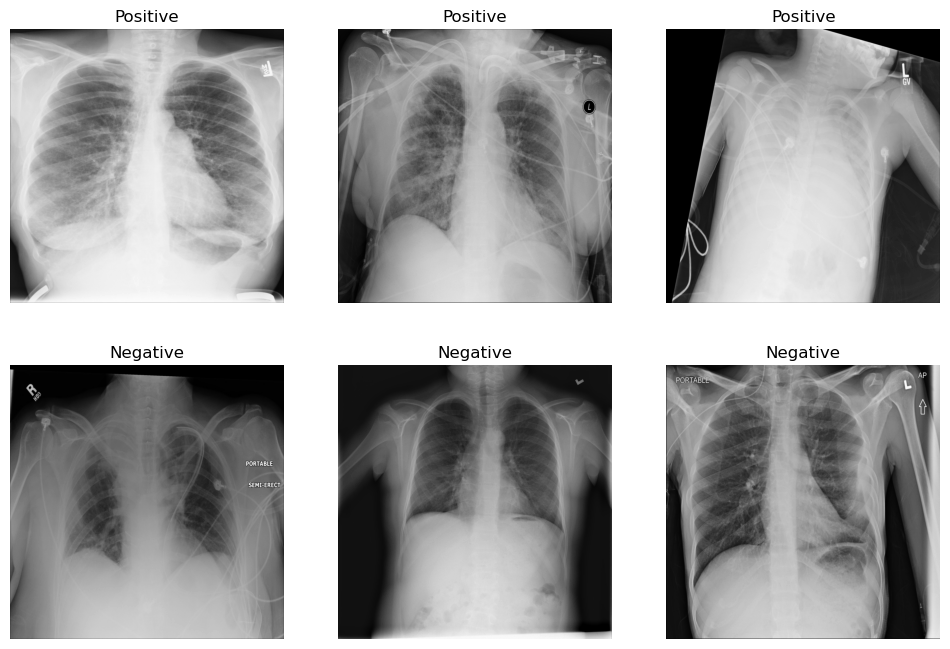

In [8]:
LABELS = pd.read_csv(LABEL_FILE)
MAPPINGS = pd.read_csv(MAPPING_FILE)
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pathlib import Path

collapsed=LABELS.groupby('patientId')["Target"].max().reset_index()

merged=pd.merge(collapsed,MAPPINGS,on='patientId',how='left',validate='one_to_one')
assert merged.shape[0] == 25684
assert merged['nih_patient_id'].isna().sum() == 0

print(merged["patientId"].nunique())
print(merged["nih_patient_id"].nunique())
print(merged["Target"].value_counts())
merged["Target"].value_counts(normalize=True)



path_index = {p.stem: p for p in DATA_ROOT.rglob("*.dcm")}
assert len(path_index) == 25684
print("Indexed files:", len(path_index))

pos_ids = merged.loc[merged["Target"] == 1, "patientId"].tolist()
neg_ids = merged.loc[merged["Target"] == 0, "patientId"].tolist()
chosen  = pos_ids[:3] + neg_ids[:3]


fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, pid in zip(axes.ravel(), chosen):
    arr   = pydicom.dcmread(path_index[pid]).pixel_array
    label = merged.loc[merged["patientId"] == pid, "Target"].iloc[0]

    ax.imshow(arr, cmap="gray")
    ax.set_title("Positive" if label == 1 else "Negative")
    ax.axis("off")

records = []
for pid, path in path_index.items():
    ds = pydicom.dcmread(path, stop_before_pixels=True)  
    records.append({
        "patientId":   pid,
        "rows":        ds.get("Rows"),
        "cols":        ds.get("Columns"),
        "photometric": ds.get("PhotometricInterpretation", "UNKNOWN"),
        "view":        ds.get("ViewPosition", "UNKNOWN"),
    })

meta = pd.DataFrame(records)

print("Image sizes (rows x cols):")
print((meta["rows"].astype(str) + " x " + meta["cols"].astype(str)).value_counts(), "\n")

print("Photometric interpretation:")
print(meta["photometric"].value_counts(), "\n")

print("View position:")
print(meta["view"].value_counts())


---
# Task B — Create leakage-safe splits

Split train/validation/test by **`nih_patient_id`** (patient-level), so no patient appears in more than one split. Assertions below prove the three patient sets are disjoint.

In [9]:
import sklearn
from sklearn.model_selection import GroupShuffleSplit
SEED = 42
gss_test=GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED)
temp_idx,test_idx=next((gss_test.split(merged,merged["Target"],merged["nih_patient_id"])))

temp_df=merged.iloc[temp_idx]
test_df=merged.iloc[test_idx]
print("temp:", temp_df.shape[0], "exams")
print("test:", test_df.shape[0], "exams")


gss_val=GroupShuffleSplit(n_splits=1,test_size=15/85,random_state=SEED)
train_idx,val_idx=next((gss_val.split(temp_df,temp_df["Target"],temp_df["nih_patient_id"])))

val_df=temp_df.iloc[val_idx]
train_df=temp_df.iloc[train_idx]

print("train:", train_df.shape[0], "exams")
print("val:", val_df.shape[0], "exams")


train_patients=set(train_df["nih_patient_id"])
val_patients=set(val_df["nih_patient_id"])
test_patients=set(test_df["nih_patient_id"])

assert len(train_patients.intersection(val_patients)) == 0
assert len(train_patients.intersection(test_patients)) == 0
assert len(val_patients.intersection(test_patients)) == 0

print("Train, val, and test patient sets are disjoint")

splits = {"train": train_df, "val": val_df, "test": test_df}
for name, df in splits.items():
    size     = df.shape[0]
    pos_prop = df["Target"].mean()
    print(f"{name:5s}  size: {size:6d}  positive proportion: {pos_prop:.3f}")







temp: 21833 exams
test: 3851 exams
train: 17947 exams
val: 3886 exams
Train, val, and test patient sets are disjoint
train  size:  17947  positive proportion: 0.217
val    size:   3886  positive proportion: 0.218
test   size:   3851  positive proportion: 0.239


### B5 — A leakage route that patient-level grouping does not prevent

Grouping by `nih_patient_id` stops the **same patient** appearing in more than one
split, but in a multi-site dataset it does **not** prevent **site/scanner leakage**.
Different sites use different scanners, exposure settings and burned-in markers
(e.g. "PORTABLE", side/orientation labels), which form an *acquisition fingerprint*.
If disease prevalence differs by site, the model can learn "this scanner signature →
positive" instead of reading the lungs. Because every split still contains all sites,
this shortcut survives into the test set and inflates the reported performance.

**How to test for it:** hold out an entire site from training and evaluate on that
unseen site (leave site out). If performance drops sharply on the held-out site
compared with same-site evaluation, the model is relying on site specific signal
rather than pathology. This requires a site/scanner label; if none is provided, a
proxy such as the DICOM manufacturer field or clustering images by acquisition
artefacts could stand in.



---
# Task C — Preprocess and augment

**C1:** DICOM → model-ready tensor. Pixels are min-max scaled to **[0, 1]** (per image, independent of bit depth), then resized to **224×224** with antialiasing and given a channel dimension → tensor of shape `(1, 224, 224)`.

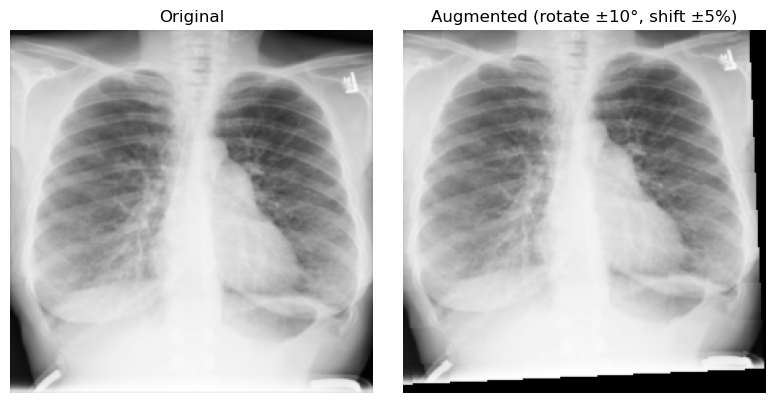

3.614811005399846


In [22]:

import numpy as np
import torch
import torchvision.transforms.functional as TF

def load_and_scale(pid):
    arr = pydicom.dcmread(path_index[pid]).pixel_array   
    arr = arr.astype("float32")                          
    arr = (arr - arr.min()) / (arr.max() - arr.min())    
    return arr
def preprocess(pid):
    arr=load_and_scale(pid)
    t=torch.from_numpy(arr).unsqueeze(0)
    t=TF.resize(t, (224, 224),antialias=True)
    return t
from torchvision import transforms 
import matplotlib.pyplot as plt
train_tf = transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),fill=0)

img=preprocess(pos_ids[0])
aug=train_tf(img)

fig, (a,b) =plt.subplots(1,2,figsize=(8,4))
a.imshow(img.squeeze(),cmap="gray"); a.set_title("Original")
a.axis("off")
b.imshow(aug.squeeze(),cmap="gray"); b.set_title("Augmented (rotate ±10°, shift ±5%)"); b.axis("off")
plt.tight_layout();plt.show()



pos_weight = (train_df["Target"] == 0).sum() / (train_df["Target"] == 1).sum()
print(pos_weight)   


The augmentations I applied are a small rotation (±10°) and a small translation (±5%). These mimic realistic acquisition variation: a patient may not lie perfectly still during the scan and, in the worst case, may be tilted or slightly off-centre against the detector. Neither transform alters the underlying anatomy.
I deliberately avoided vertical flips, horizontal flips, and heavy rotation, because they produce anatomically implausible images  positions a real patient could not be scanned in. In particular, a horizontal flip mirrors left and right, which would move the heart to the right side , changing the clinical meaning of the image. A vertical flip would present an upside-down chest, which is impossible. Augmentations must expand realistic variation without inventing anatomy that does not occur, so these were excluded.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix
y_true=test_df["Target"].values
marjority_class=train_df["Target"].mode()[0]
y_pred = np.full(len(y_true),marjority_class)

accuracy=accuracy_score(y_true,y_pred)
recall=recall_score(y_true,y_pred)
tn, fp, fn, tp = confusion_matrix(y_true,y_pred).ravel()
specificity=tn/(tn+fp)
print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
def extract_features(pid):
     arr=load_and_scale(pid)
     return np.array([arr.mean(),arr.std(),np.percentile(arr,10),np.percentile(arr,50),np.percentile(arr,90),])
     


X_train = np.array([extract_features(pid) for pid in train_df["patientId"]])
y_train = train_df["Target"].values

X_val = np.array([extract_features(pid) for pid in val_df["patientId"]])
y_val = val_df["Target"].values

X_test = np.array([extract_features(pid) for pid in test_df["patientId"]])
y_test = test_df["Target"].values

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

np.savez("baseline_features.npz", X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   
X_val_s   = scaler.transform(X_val)         
X_test_s  = scaler.transform(X_test) 


import torch, torch.nn as nn
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

# --- features/labels to tensors ---
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train,   dtype=torch.float32).unsqueeze(1)
Xva = torch.tensor(X_val_s,   dtype=torch.float32)
Xte = torch.tensor(X_test_s,  dtype=torch.float32)


def train_logistic(pos_weight=None, epochs=300, lr=0.01):
    torch.manual_seed(42)                     
    model = nn.Linear(5, 1)
    pw = torch.tensor([pos_weight], dtype=torch.float32) if pos_weight else None
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        opt.step()
    return model


def evaluate(model, X, y_true):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X)).squeeze().numpy()
    y_pred = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"accuracy":    round(accuracy_score(y_true, y_pred), 3),
            "sensitivity": round(recall_score(y_true, y_pred, zero_division=0), 3),
            "specificity": round(tn / (tn + fp), 3)}


model_plain    = train_logistic(pos_weight=None)
model_weighted = train_logistic(pos_weight=3.615)

print("C4 comparison (validation):")
print("  WITHOUT pos_weight:", evaluate(model_plain,    Xva, y_val))
print("  WITH    pos_weight:", evaluate(model_weighted, Xva, y_val))


final_model = model_weighted
print("\nFinal logistic baseline (TEST, evaluated once):")
print(" ", evaluate(final_model, Xte, y_test))






Accuracy: 0.761
Recall: 0.000
Specificity: 1.000
X_train: (17947, 5) y_train: (17947,)
X_val:   (3886, 5) y_val:   (3886,)
X_test:  (3851, 5) y_test:  (3851,)
C4 comparison (validation):
  WITHOUT pos_weight: {'accuracy': 0.781, 'sensitivity': 0.0, 'specificity': 0.999}
  WITH    pos_weight: {'accuracy': 0.658, 'sensitivity': 0.604, 'specificity': 0.673}

Final logistic baseline (TEST, evaluated once):
  {'accuracy': 0.653, 'sensitivity': 0.591, 'specificity': 0.672}
